In [1]:
# Import libraries for LSTM-based weather forecasting

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Load daily weather dataset

url = "https://raw.githubusercontent.com/florian-huber/weather_prediction_dataset/master/weather_prediction_dataset.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

HTTPError: HTTP Error 404: Not Found

In [3]:
# Download the Jena weather dataset

url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"

df = pd.read_csv(url, compression="zip")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (420551, 15)

Columns:
['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [4]:
# Convert timestamp and create daily averages

df["Date Time"] = pd.to_datetime(df["Date Time"], dayfirst=True)

daily_df = (
    df.set_index("Date Time")
      .resample("D")[["T (degC)", "p (mbar)", "rh (%)", "wv (m/s)"]]
      .mean()
      .dropna()
      .reset_index()
)

print("Daily dataset shape:", daily_df.shape)
display(daily_df.head())

Daily dataset shape: (2921, 5)


,Date Time,T (degC),p (mbar),rh (%),wv (m/s)
0,2009-01-01,-6.810629,999.145594,91.086014,0.778601
1,2009-01-02,-3.728194,999.600625,92.086806,1.419514
2,2009-01-03,-5.271736,998.548611,76.458056,1.250903
3,2009-01-04,-1.375208,988.510694,89.417361,1.720417
4,2009-01-05,-4.867153,990.405694,86.260417,3.800278


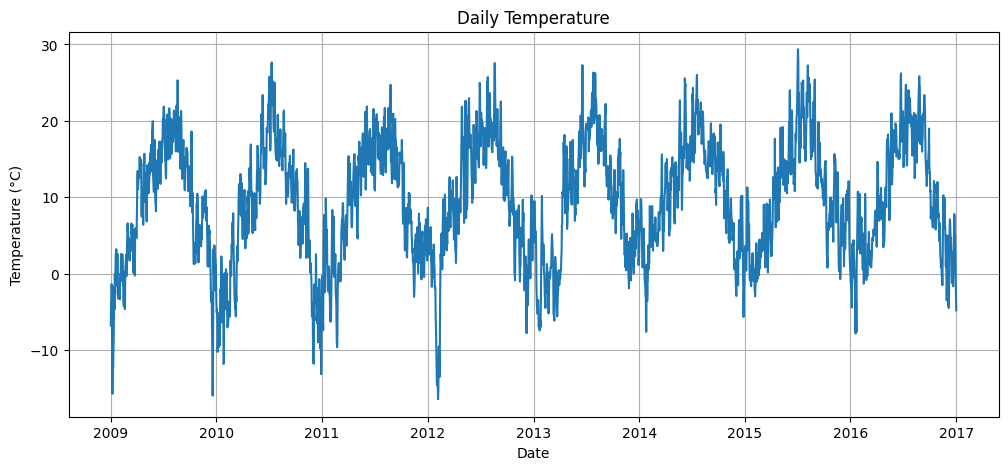

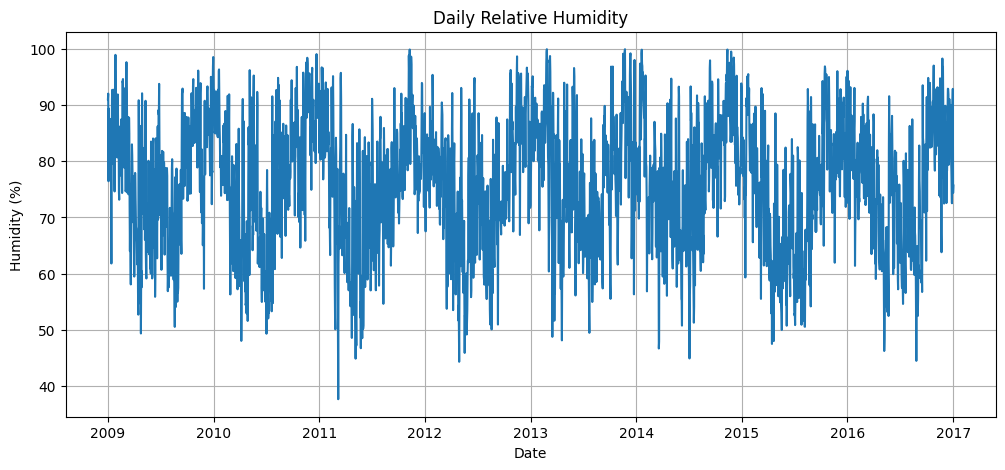

In [5]:
# Visualize daily weather variables

plt.figure(figsize=(12, 5))
plt.plot(daily_df["Date Time"], daily_df["T (degC)"])
plt.title("Daily Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(daily_df["Date Time"], daily_df["rh (%)"])
plt.title("Daily Relative Humidity")
plt.xlabel("Date")
plt.ylabel("Humidity (%)")
plt.grid(True)
plt.show()

In [6]:
# Select input features and target

features = ["T (degC)", "p (mbar)", "rh (%)", "wv (m/s)"]

data = daily_df[features].values

# Chronological 80-20 split
split = int(len(data) * 0.8)

train_data = data[:split]
test_data = data[split:]

# Normalize using training data only
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))
print("Input features:", features)
print("Scaled training shape:", train_scaled.shape)
print("Scaled testing shape:", test_scaled.shape)

Training samples: 2336
Testing samples: 585
Input features: ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)']
Scaled training shape: (2336, 4)
Scaled testing shape: (585, 4)


In [7]:
# Create 30-day sequences for LSTM

time_steps = 30

def create_sequences(data, time_steps):
    X, y = [], []

    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i])
        y.append(data[i, 0])  # Temperature

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, time_steps)
X_test, y_test = create_sequences(test_scaled, time_steps)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2306, 30, 4)
y_train shape: (2306,)
X_test shape: (555, 30, 4)
y_test shape: (555,)


In [8]:
# Build LSTM model

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_steps, 4)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,251 (122.07 KB)

 Trainable params: 31,251 (122.07 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Build LSTM model

from tensorflow.keras import Input

model = Sequential([
    Input(shape=(time_steps, 4)),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 50)         │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,251 (122.07 KB)

 Trainable params: 31,251 (122.07 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train the LSTM model

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.0469 - val_loss: 0.0054
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0129 - val_loss: 0.0060
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0111 - val_loss: 0.0049
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0111 - val_loss: 0.0056
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0101 - val_loss: 0.0049
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0096 - val_loss: 0.0057
Epoch 7/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0092 - val_loss: 0.0048
Epoch 8/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0091 - val_loss: 0.0049
Epoch 9/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0089 - val_loss: 0.0046
Epoch 10/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0084 - val_loss: 0.0049
Epoch 11/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0082 - val_loss: 0.0050
Epoch 12/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0

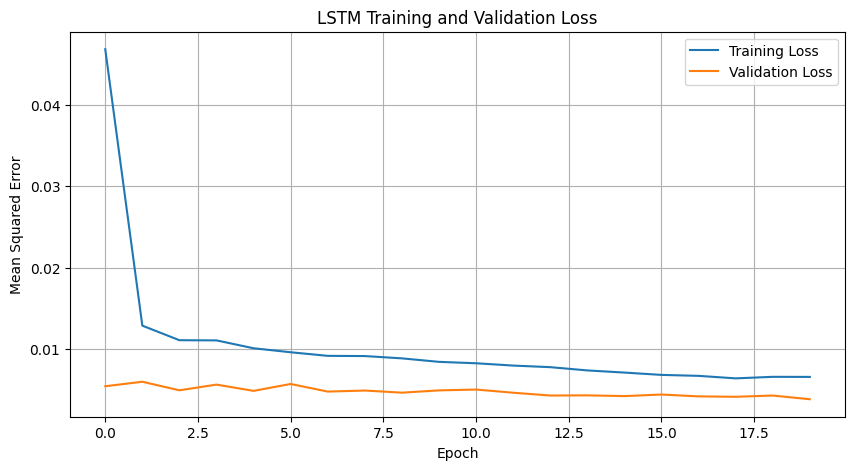

In [11]:
# Plot training and validation loss

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# Generate predictions on test data

y_pred_scaled = model.predict(X_test)

# Convert predictions and actual values back to Celsius
y_pred = scaler.inverse_transform(
    np.column_stack([
        y_pred_scaled.flatten(),
        np.zeros((len(y_pred_scaled), 3))
    ])
)[:, 0]

y_actual = scaler.inverse_transform(
    np.column_stack([
        y_test,
        np.zeros((len(y_test), 3))
    ])
)[:, 0]

print("Predictions generated:", len(y_pred))
print("Actual values:", len(y_actual))

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
Predictions generated: 555
Actual values: 555


In [13]:
# Evaluate forecasting performance

mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

print(f"Mean Absolute Error (MAE): {mae:.4f} °C")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} °C")

Mean Absolute Error (MAE): 2.3454 °C
Root Mean Squared Error (RMSE): 2.9161 °C


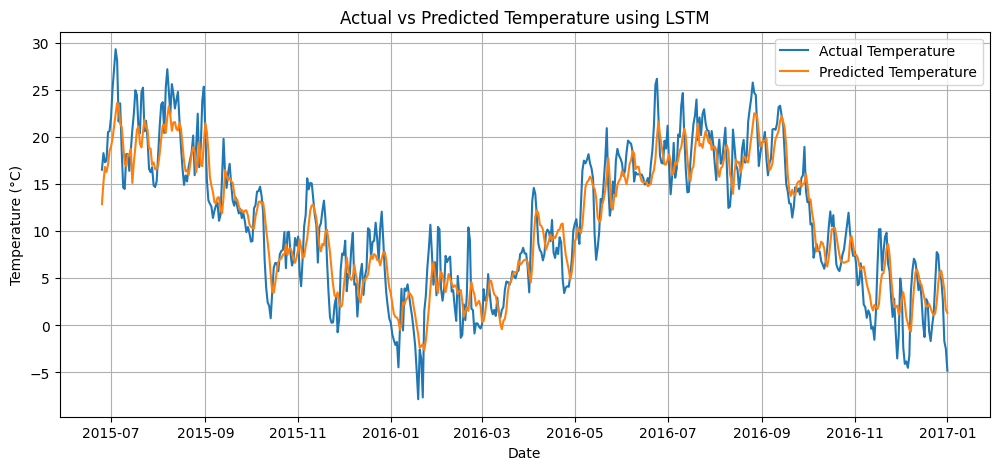

In [14]:
# Plot actual vs predicted temperature

test_dates = daily_df["Date Time"].iloc[split + time_steps:].reset_index(drop=True)

plt.figure(figsize=(12, 5))

plt.plot(test_dates, y_actual, label="Actual Temperature")
plt.plot(test_dates, y_pred, label="Predicted Temperature")

plt.title("Actual vs Predicted Temperature using LSTM")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()